**COMPARACIÓN CONSUMOS LEIDOS DEL INVERSOR CON CONSUMOS FACTURADOS POR LA COMERCIALIZADORA**

In [1]:
import pandas as pd
df_consumos_inverter = pd.read_csv('inverter_consumos_clean.csv')
df_consumos_facturados = pd.read_csv('consumos_facturados_clean.csv')

In [2]:
# convertir index a datetime en formato yyyy-mm-dd hh:mm zona
df_consumos_facturados = df_consumos_facturados[[
  'Fecha Factura',
  'Fecha Minima Término Energia',
  'Fecha Maxima Término Energia',
  'Consumo',
]]
df_consumos_facturados.tail()

,Fecha Factura,Fecha Minima Término Energia,Fecha Maxima Término Energia,Consumo
46,2024-10-09,2024-09-05,2024-10-06,481.0
47,2024-11-12,2024-10-06,2024-11-07,603.0
48,2024-12-11,2024-11-07,2024-12-08,750.0
49,2025-01-13,2024-12-08,2025-01-08,685.0
50,2025-02-18,2025-01-08,2025-02-11,875.0


In [3]:
# limitar los df al perido de estudio (1ª factura octubre 2023 y última diciembre 2024)
df_consumos_facturados = df_consumos_facturados[
  (df_consumos_facturados['Fecha Factura'] >= '2023-10-09') &
  (df_consumos_facturados['Fecha Factura'] <= '2025-02-18')
]
df_consumos_facturados.tail()

,Fecha Factura,Fecha Minima Término Energia,Fecha Maxima Término Energia,Consumo
46,2024-10-09,2024-09-05,2024-10-06,481.0
47,2024-11-12,2024-10-06,2024-11-07,603.0
48,2024-12-11,2024-11-07,2024-12-08,750.0
49,2025-01-13,2024-12-08,2025-01-08,685.0
50,2025-02-18,2025-01-08,2025-02-11,875.0


In [4]:
df_consumos_facturados.rename(columns={
  'Fecha Factura': 'fecha_factura',
  'Fecha Minima Término Energia': 'fecha_minima',
  'Fecha Maxima Término Energia': 'fecha_maxima',
  }, inplace=True)
df_consumos_facturados['fecha_factura'] = pd.to_datetime(df_consumos_facturados['fecha_factura'])
df_consumos_facturados['fecha_minima'] = pd.to_datetime(df_consumos_facturados['fecha_minima'])
df_consumos_facturados['fecha_maxima'] = pd.to_datetime(df_consumos_facturados['fecha_maxima'])
df_consumos_facturados.tail()

,fecha_factura,fecha_minima,fecha_maxima,Consumo
46,2024-10-09,2024-09-05,2024-10-06,481.0
47,2024-11-12,2024-10-06,2024-11-07,603.0
48,2024-12-11,2024-11-07,2024-12-08,750.0
49,2025-01-13,2024-12-08,2025-01-08,685.0
50,2025-02-18,2025-01-08,2025-02-11,875.0


In [5]:
df_consumos_inverter = df_consumos_inverter[
  (df_consumos_inverter['date_time'] > '2023-09-05') &
  (df_consumos_inverter['date_time'] <= '2025-02-11')
]

In [6]:
df_consumos_inverter['consumo_facturar'] = df_consumos_inverter['consumido'] - df_consumos_inverter['autoconsumo']
df_consumos_inverter.tail()

,date_time,date,time,weekday,generado,consumido,autoconsumo,consumo_facturar
157318,2025-02-10 23:35,2025-02-10,23:35,Monday,0.0,0.304,0.0,0.304
157319,2025-02-10 23:40,2025-02-10,23:40,Monday,0.0,0.483,0.0,0.483
157320,2025-02-10 23:45,2025-02-10,23:45,Monday,0.0,0.305,0.0,0.305
157321,2025-02-10 23:50,2025-02-10,23:50,Monday,0.0,0.249,0.0,0.249
157322,2025-02-10 23:55,2025-02-10,23:55,Monday,0.0,0.309,0.0,0.309


In [7]:
# Obtener la serie de consumos diarios
df_consumos_inverter_dia = df_consumos_inverter.groupby(df_consumos_inverter['date'])['consumo_facturar'].sum().reset_index()
df_consumos_inverter_dia['date'] = pd.to_datetime(df_consumos_inverter_dia['date'])
df_consumos_inverter_dia.tail()

,date,consumo_facturar
519,2025-02-06,255.793
520,2025-02-07,438.409
521,2025-02-08,300.365
522,2025-02-09,381.028
523,2025-02-10,418.961


In [8]:
# Agrupar los consumos inverter a las fechas que tenemos de los consumos facturados
def asignar_periodo(fecha, df_periodos):
  for _, row in df_periodos.iterrows():
    if row['fecha_minima'] < fecha <= row['fecha_maxima']:
      return row['fecha_maxima']
  return None
df_consumos_inverter_dia['periodo'] = df_consumos_inverter_dia['date'].apply(asignar_periodo, df_periodos=df_consumos_facturados)
df_consumos_inverter_dia.tail()

,date,consumo_facturar,periodo
519,2025-02-06,255.793,2025-02-11
520,2025-02-07,438.409,2025-02-11
521,2025-02-08,300.365,2025-02-11
522,2025-02-09,381.028,2025-02-11
523,2025-02-10,418.961,2025-02-11


In [9]:
df_consumos_inverter_periodo = df_consumos_inverter_dia.groupby(df_consumos_inverter_dia['periodo'])['consumo_facturar'].sum().reset_index()
df_consumos_inverter_periodo['consumo_facturar_12'] = df_consumos_inverter_periodo['consumo_facturar'] / 12
df_consumos_inverter_periodo['anno_mes'] = df_consumos_inverter_periodo['periodo'].dt.to_period('M')
df_consumos_inverter_periodo.tail()

,periodo,consumo_facturar,consumo_facturar_12,anno_mes
12,2024-10-06,5723.338,476.944833,2024-10
13,2024-11-07,7140.145,595.012083,2024-11
14,2024-12-08,8914.292,742.857667,2024-12
15,2025-01-08,8137.822,678.151833,2025-01
16,2025-02-11,10132.137,844.344750,2025-02


In [10]:
df_consumos_facturados['anno_mes'] = df_consumos_facturados['fecha_maxima'].dt.to_period('M')
df_consumos_facturados.tail()

,fecha_factura,fecha_minima,fecha_maxima,Consumo,anno_mes
46,2024-10-09,2024-09-05,2024-10-06,481.0,2024-10
47,2024-11-12,2024-10-06,2024-11-07,603.0,2024-11
48,2024-12-11,2024-11-07,2024-12-08,750.0,2024-12
49,2025-01-13,2024-12-08,2025-01-08,685.0,2025-01
50,2025-02-18,2025-01-08,2025-02-11,875.0,2025-02


In [11]:
df_compara_consumo_factura = df_consumos_inverter_periodo.merge(df_consumos_facturados, on='anno_mes', how='left')
df_compara_consumo_factura['diferencia'] = df_compara_consumo_factura['Consumo'] - df_compara_consumo_factura['consumo_facturar_12']
df_compara_consumo_factura.tail(30)

,periodo,consumo_facturar,consumo_facturar_12,anno_mes,fecha_factura,fecha_minima,fecha_maxima,Consumo,diferencia
0,2023-10-04,2515.900,209.658333,2023-10,2023-10-09,2023-09-05,2023-10-04,213.0,3.341667
1,2023-11-06,4419.218,368.268167,2023-11,2023-11-09,2023-10-04,2023-11-06,372.0,3.731833
2,2023-12-04,4332.235,361.019583,2023-12,2023-12-11,2023-11-06,2023-12-04,364.0,2.980417
3,2024-01-04,6134.405,511.200417,2024-01,2024-01-09,2023-12-04,2024-01-04,517.0,5.799583
4,2024-02-06,5865.739,488.811583,2024-02,2024-02-09,2024-01-04,2024-02-06,519.0,30.188417
5,2024-03-06,4438.290,369.857500,2024-03,2024-03-11,2024-02-06,2024-03-06,373.0,3.142500
6,2024-04-04,4048.222,337.351833,2024-04,2024-04-09,2024-03-06,2024-04-04,364.0,26.648167
7,2024-05-07,4023.906,335.325500,2024-05,2024-05-10,2024-04-04,2024-05-07,340.0,4.674500
8,2024-06-06,4533.513,377.792750,2024-06,2024-06-11,2024-05-07,2024-06-06,384.0,6.207250
9,2024-07-04,4396.406,366.367167,2024-07,2024-07-09,2024-06-06,2024-07-04,369.0,2.632833


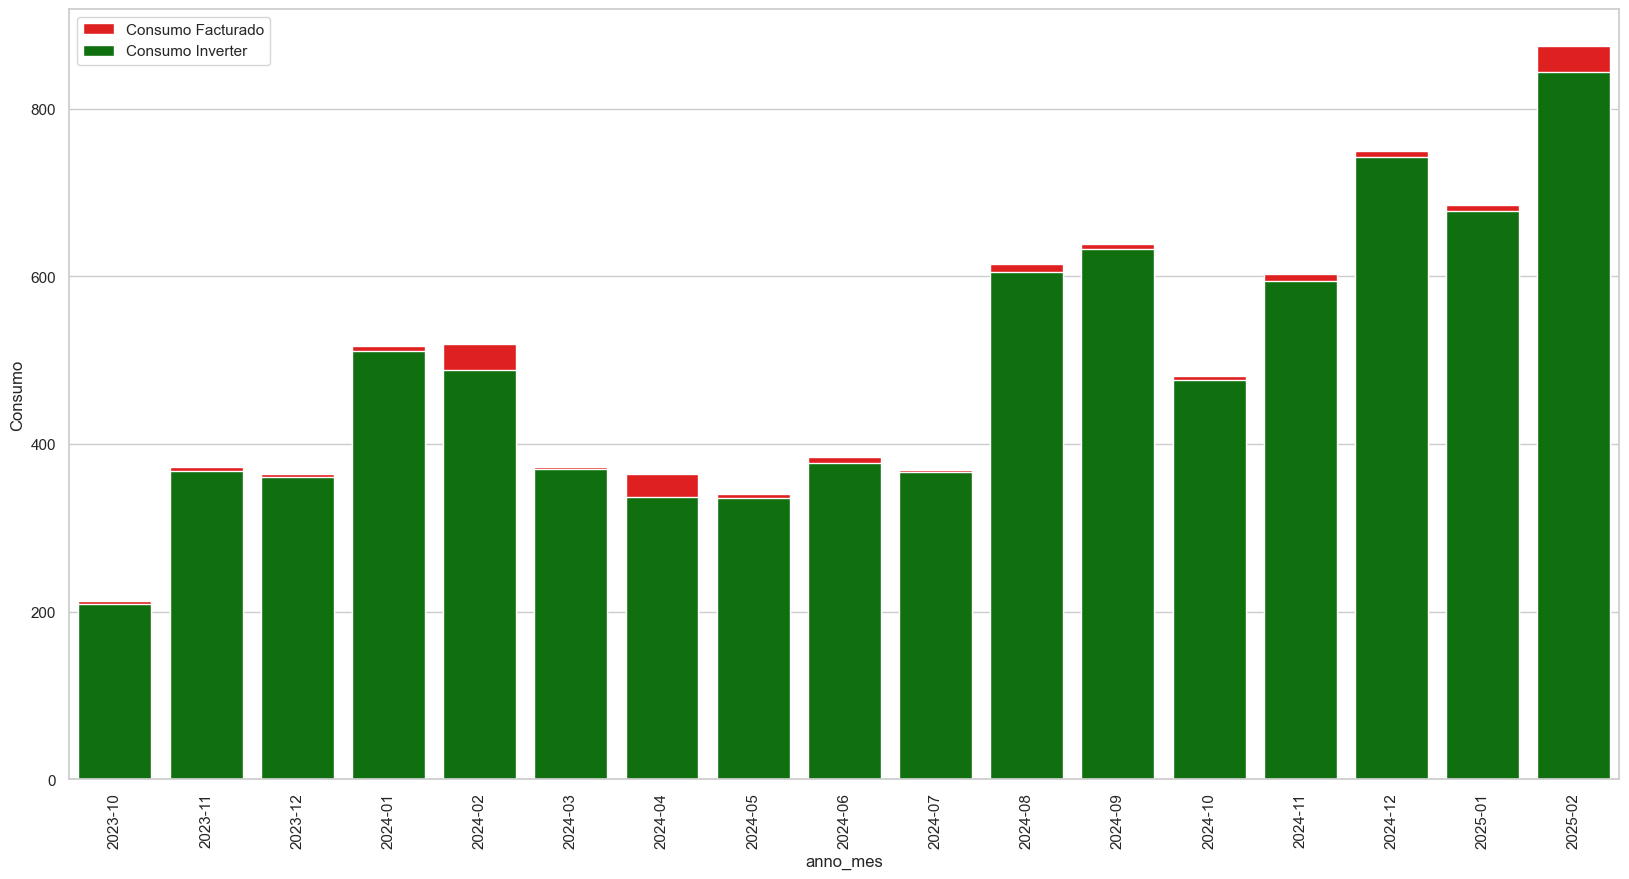

In [12]:
# Gráfico de barras de los consumos facturados y los consumos del inverter
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")  # set style for seaborn plots
plt.figure(figsize=(20, 10))
sns.barplot(data=df_compara_consumo_factura, x='anno_mes', y='Consumo', color='red', label='Consumo Facturado')
sns.barplot(data=df_compara_consumo_factura, x='anno_mes', y='consumo_facturar_12', color='green', label='Consumo Inverter')
plt.xticks(rotation=90)
plt.legend()
plt.show()
